# Análisis exploratorio de datos: dataset de TikTok

Este notebook realiza un análisis exploratorio y estadístico sobre un dataset de videos de TikTok, con el objetivo de caracterizar la duración de los videos y estimar, mediante estadística inferencial, el rango en el que se ubica su duración promedio real.

In [40]:
# Importar librerias pandas y numpy
import pandas as pd
import numpy as np
import scipy.stats as st

# Importar librerias para visualizar graficos
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Exploración inicial del dataset

Se carga el dataset y se revisa su estructura general: dimensiones, tipos de datos, valores nulos y estadísticos descriptivos básicos.

In [31]:
# cargar el dataset de tiktok
data = pd.read_csv("tiktok_dataset.csv")

# visualizar el dataframe los r primeros registros
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [32]:
#revision de los ultimos 5 registros
data.tail()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
19377,19378,NaN,7578226840,21,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19378,19379,NaN,6079236179,53,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19379,19380,NaN,2565539685,10,NaN,verified,under review,NaN,NaN,NaN,NaN,NaN
19380,19381,NaN,2969178540,24,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19381,19382,NaN,8132759688,13,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN


In [33]:
# ver el tamaño de la data
data.size

232584

In [34]:
# ver la cantidad de filas y columnas
data.shape

(19382, 12)

In [35]:
# identificar la informacion del dataframe,tipo, si exieten nulos

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [36]:
# Generar una tabla de descripcion  de los datos
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


## 2. Distribución de la duración de los videos

Se visualiza la distribución de la variable `video_duration_sec` mediante un boxplot y un histograma, para identificar su forma, dispersión y posibles valores atípicos.

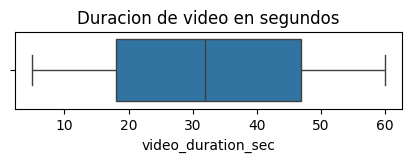

In [37]:
# Crear un boxplot para visualizar la distribucion de la duracion de los videos "video_duration_sec"
plt.figure(figsize=(5,1))
plt.title('Duracion de video en segundos')
sns.boxplot(x=data['video_duration_sec']);

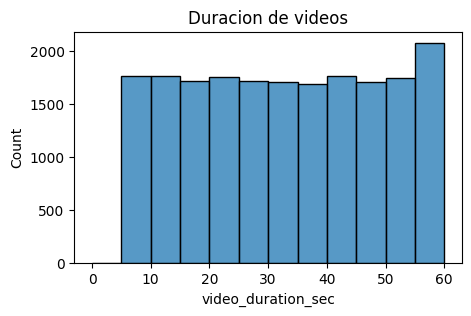

In [38]:
plt.figure(figsize=(5,3))
sns.histplot(data['video_duration_sec'], bins=range(0,61,5))
plt.title('Duracion de videos');


## 3. Estadística descriptiva

Se calculan la media, varianza y desviación estándar de la duración de los videos.

In [41]:
# calcular la media, la varianza y la desviacion standar
media = np.mean(data["video_duration_sec"])
varianza = np.var(data["video_duration_sec"])
desviacion_estandar = np.std(data["video_duration_sec"])

print("media:", round(media, 2))
print("varianza:", round(varianza, 2))
print("desviacion estandar:", round(desviacion_estandar, 2))

media: 32.42
varianza: 263.4
desviacion estandar: 16.23


## 4. Estimación por intervalo de confianza

Se calcula un intervalo de confianza del 95% para estimar el rango en que se encuentra la duración promedio real de los videos en la población.

In [42]:
#calculo del intervalo de confianza

media = np.mean(data["video_duration_sec"])
desviacion_estandar = np.std(data["video_duration_sec"])
n = len(data["video_duration_sec"])

intervalo_confianza = st.t.interval(0.95, n-1, loc=media, scale=desviacion_estandar/np.sqrt(n))

print("El intervalo de confianza es: (", round(intervalo_confianza[0],2), ",", round(intervalo_confianza[1],2), ")")

El intervalo de confianza es: ( 32.19 , 32.65 )
